# POUNCE from CasADi

[CasADi](https://web.casadi.org/) is a symbolic framework for nonlinear
optimization and algorithmic differentiation. POUNCE registers with it as an
`nlpsol` **plugin**, so a CasADi model hands its problem to POUNCE exactly the
way it would hand it to Ipopt:

```python
solver = ca.nlpsol("solver", "pounce", nlp, {"pounce": {"tol": 1e-9}})
```

Because it is a genuine plugin and not a Python-side wrapper, everything
CasADi layers on top of a solver keeps working: `Opti`, MX graphs, parameters,
embedding a solve inside another `Function`, and differentiating through the
solve.

**Setup.** The plugin is a small C++ shared library built against the CasADi
you have installed — there is no wheel yet:

```sh
pip install casadi
git clone https://github.com/jkitchin/pounce && cd pounce
cargo build --release -p pounce-cinterface
cd casadi && make fetch-src && make && make install
```

`make install` drops the plugin into CasADi's own package directory, which its
loader searches first, so nothing else is needed. If you skipped that step, set
`CASADIPATH` to the repository's `casadi/` directory before starting Jupyter.
Full details: [`docs/src/casadi.md`](../../docs/src/casadi.md).

In [1]:
import time

import casadi as ca
import numpy as np

# Fail early and clearly if the plugin is not on CasADi's search path.
_probe = ca.MX.sym("probe")
try:
    ca.nlpsol("probe", "pounce", {"x": _probe, "f": _probe**2})
except RuntimeError as exc:
    raise SystemExit(
        "The POUNCE plugin is not loadable. Build and install it with\n"
        "  cd casadi && make fetch-src && make && make install\n"
        "or set CASADIPATH to the repository's casadi/ directory.\n\n"
        f"{exc}"
    ) from None

print("casadi", ca.__version__, "— pounce plugin loaded")

casadi 3.7.2 — pounce plugin loaded


## 1. A first solve

Rosenbrock inside a circle of radius $\sqrt{p}$, with $p$ a **parameter** —
one solver object, re-callable at any $p$:

$$\min_x \; (1-x_0)^2 + 100(x_1 - x_0^2)^2 \quad\text{s.t.}\quad x_0^2 + x_1^2 \le p$$

Options for the solver itself go in the `pounce` dict and use
Ipopt-compatible names, so an `ipopt.opt` you already have translates
directly.

In [2]:
x = ca.MX.sym("x", 2)
p = ca.MX.sym("p")

nlp = {
    "x": x,
    "p": p,
    "f": (1 - x[0]) ** 2 + 100 * (x[1] - x[0] ** 2) ** 2,
    "g": x[0] ** 2 + x[1] ** 2 - p,
}

solver = ca.nlpsol("solver", "pounce", nlp, {
    "print_time": False,
    "pounce": {"print_level": 0, "tol": 1e-9},
})

sol = solver(x0=[0.5, 0.5], p=1.5, lbg=-ca.inf, ubg=0)

print("x*    ", sol["x"].full().ravel())
print("f(x*) ", float(sol["f"]))
print("lam_g ", sol["lam_g"].full().ravel())
print("lam_x ", sol["lam_x"].full().ravel())

x*     [0.90723396 0.82275546]
f(x*)  0.008615650364308444
lam_g  [0.03865095]
lam_x  [0. 0.]


### Statistics

`stats()` carries CasADi's usual keys plus POUNCE's full per-iteration trace —
the same columns its iteration table prints, so a convergence plot needs no
stdout parsing.

In [3]:
st = solver.stats()
print("success      ", st["success"])
print("return_status", st["return_status"])
print("iterations   ", st["iter_count"])
print("trace keys   ", sorted(st["iterations"]))

success       True
return_status Solve_Succeeded
iterations    13
trace keys    ['alpha_du', 'alpha_pr', 'd_norm', 'inf_du', 'inf_pr', 'ls_trials', 'mu', 'obj', 'regularization_size']


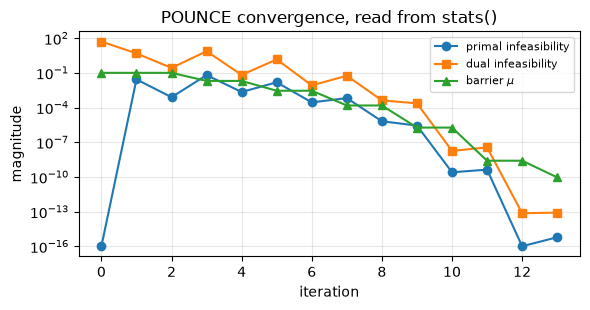

In [4]:
import matplotlib.pyplot as plt

it = st["iterations"]
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.semilogy(np.maximum(it["inf_pr"], 1e-16), "o-", label="primal infeasibility")
ax.semilogy(np.maximum(it["inf_du"], 1e-16), "s-", label="dual infeasibility")
ax.semilogy(np.maximum(it["mu"], 1e-16), "^-", label=r"barrier $\mu$")
ax.set_xlabel("iteration")
ax.set_ylabel("magnitude")
ax.set_title("POUNCE convergence, read from stats()")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()

## 2. `Opti`

`Opti` is CasADi's modelling front end, and it accepts an `nlpsol` **plugin
name** — which is exactly what POUNCE registers. A minimum-effort rocket
ascent, 40 control intervals:

Solve_Succeeded in 5 iterations
control effort 11.200750469043149


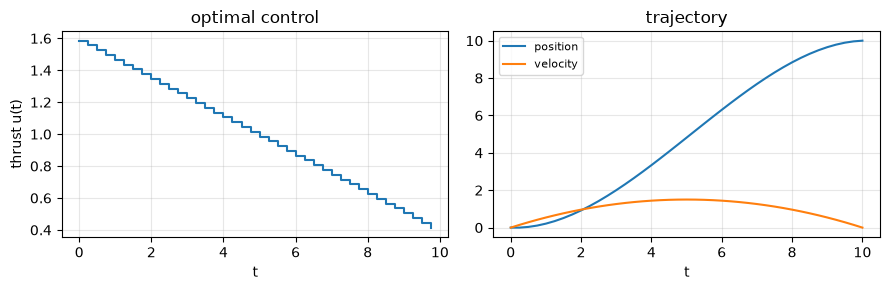

In [5]:
N, T, u_max = 40, 10.0, 3.0
dt = T / N

opti = ca.Opti()
pos, vel, u = opti.variable(N + 1), opti.variable(N + 1), opti.variable(N)

for k in range(N):  # explicit Euler: ṗ = v, v̇ = u − g
    opti.subject_to(pos[k + 1] == pos[k] + dt * vel[k])
    opti.subject_to(vel[k + 1] == vel[k] + dt * (u[k] - 1.0))

opti.subject_to(opti.bounded(0, u, u_max))
opti.subject_to(pos[0] == 0)
opti.subject_to(vel[0] == 0)
opti.subject_to(pos[N] == 10)
opti.subject_to(vel[N] == 0)
opti.minimize(dt * ca.sumsqr(u))
opti.set_initial(u, 1.0)

opti.solver("pounce", {"print_time": False}, {"print_level": 0, "tol": 1e-8})
ocp = opti.solve()

print(ocp.stats()["return_status"], "in", ocp.stats()["iter_count"], "iterations")
print("control effort", float(ocp.value(dt * ca.sumsqr(u))))

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].step(np.arange(N) * dt, ocp.value(u), where="post")
ax[0].set(xlabel="t", ylabel="thrust u(t)", title="optimal control")
ax[1].plot(np.arange(N + 1) * dt, ocp.value(pos), label="position")
ax[1].plot(np.arange(N + 1) * dt, ocp.value(vel), label="velocity")
ax[1].set(xlabel="t", title="trajectory")
ax[1].legend(fontsize=8)
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout()

## 3. Warm starting a receding-horizon loop

Build the solver once, call it per step with a new parameter value and the
previous solution. Two options make the multipliers you pass actually count —
without them they are outputs only, which is Ipopt's contract too:

```python
"warm_start_init_point": "yes",
"mu_init": 1e-6,
```

In [6]:
Nh, dth = 20, 0.1
X = ca.MX.sym("X", 2, Nh + 1)
U = ca.MX.sym("U", 1, Nh)
x0_par = ca.MX.sym("x0_par", 2)

cost, cons = 0, [X[:, 0] - x0_par]
for k in range(Nh):
    nxt = ca.vertcat(
        X[0, k] + dth * X[1, k],
        X[1, k] + dth * (U[0, k] - 0.1 * X[1, k] * ca.fabs(X[1, k])),
    )
    cons.append(X[:, k + 1] - nxt)
    cost += X[0, k] ** 2 + 0.1 * X[1, k] ** 2 + 0.01 * U[0, k] ** 2
cost += 10 * (X[0, Nh] ** 2 + X[1, Nh] ** 2)

mpc_nlp = {"x": ca.vertcat(ca.vec(X), ca.vec(U)), "p": x0_par,
           "f": cost, "g": ca.vertcat(*cons)}
nx = 2 * (Nh + 1) + Nh

cold = ca.nlpsol("cold", "pounce", mpc_nlp,
                 {"print_time": False, "pounce": {"print_level": 0, "tol": 1e-8}})
warm = ca.nlpsol("warm", "pounce", mpc_nlp, {"print_time": False, "pounce": {
    "print_level": 0, "tol": 1e-8,
    "warm_start_init_point": "yes", "mu_init": 1e-6}})

bounds = dict(lbg=0, ubg=0,
              lbx=[-ca.inf] * (2 * (Nh + 1)) + [-2.0] * Nh,
              ubx=[ca.inf] * (2 * (Nh + 1)) + [2.0] * Nh)

state, prev = ca.DM([1.0, 0.0]), None
cold_iters, warm_iters = [], []
for step in range(8):
    args = dict(p=state, **bounds)
    cold(x0=ca.DM.zeros(nx), **args)          # reference: what a cold solve costs
    cold_iters.append(cold.stats()["iter_count"])

    if prev is None:
        prev = cold(x0=ca.DM.zeros(nx), **args)
    else:
        prev = warm(x0=prev["x"], lam_g0=prev["lam_g"], lam_x0=prev["lam_x"], **args)
        warm_iters.append(warm.stats()["iter_count"])

    u0 = float(prev["x"][2 * (Nh + 1)])
    pos_, vel_ = float(state[0]), float(state[1])
    state = ca.DM([pos_ + dth * vel_, vel_ + dth * (u0 - 0.1 * vel_ * abs(vel_))])

print("cold:", cold_iters, f"(mean {np.mean(cold_iters):.1f})")
print("warm:", warm_iters, f"(mean {np.mean(warm_iters):.1f})")

cold: [9, 9, 8, 8, 8, 8, 8, 7] (mean 8.1)
warm: [7, 7, 6, 5, 4, 4, 4] (mean 5.3)


## 4. Differentiating through the solve

An `nlpsol` object is a CasADi `Function`, so it composes into bigger graphs
and can be differentiated: CasADi's `Nlpsol` base class builds forward and
adjoint derivatives of the solution map by linearizing the KKT system at the
returned point, and every plugin inherits that. The result is exact (implicit
function theorem), not a finite difference — but it is only as good as the
multipliers, so tighten `tol` if sensitivities look off.

In [7]:
xs = ca.MX.sym("x", 2)
ps = ca.MX.sym("p", 2)

# min (x0-p0)^2 + (x1-p1)^2  s.t.  ||x|| <= 1
proj = ca.nlpsol("proj", "pounce", {
    "x": xs, "p": ps,
    "f": (xs[0] - ps[0]) ** 2 + (xs[1] - ps[1]) ** 2,
    "g": xs[0] ** 2 + xs[1] ** 2 - 1,
}, {"print_time": False, "pounce": {"print_level": 0, "tol": 1e-12}})

r = proj(x0=[0.1, 0.1], p=ps, lbg=-ca.inf, ubg=0)
x_of_p = ca.Function("x_of_p", [ps], [r["x"]])
dx_dp = ca.Function("dx_dp", [ps], [ca.jacobian(r["x"], ps)])

p_val = ca.DM([2.0, 1.0])
eps = 1e-6
fd = ca.DM.zeros(2, 2)
for j in range(2):
    d = ca.DM.zeros(2)
    d[j] = eps
    fd[:, j] = (x_of_p(p_val + d) - x_of_p(p_val - d)) / (2 * eps)

print("x*(p)          ", x_of_p(p_val).full().ravel())
print("dx*/dp         ", dx_dp(p_val).full().tolist())
print("central diff   ", fd.full().tolist())
print("max difference ", float(ca.norm_inf(dx_dp(p_val) - fd)))

x*(p)           [0.8944272 0.4472136]
dx*/dp          [[0.0894427195468434, -0.17888543909368673], [-0.17888543909368676, 0.3577708781873735]]
central diff    [[0.08944271956412564, -0.17888543912825128], [-0.17888543907274013, 0.35777087817323583]]
max difference  3.456454567007938e-11


Because the solve is differentiable, it can sit *inside* another
optimization — a bilevel problem in four lines: choose the parameter $p$ so
that the inner solution lands on a target.

In [8]:
target = ca.DM([0.6, 0.8])
q = ca.MX.sym("q", 2)
inner = proj(x0=[0.1, 0.1], p=q, lbg=-ca.inf, ubg=0)["x"]

outer = ca.nlpsol("outer", "pounce", {"x": q, "f": ca.sumsqr(inner - target)},
                  {"print_time": False, "pounce": {"print_level": 0}})
best = outer(x0=[2.0, 1.0])

print("p*        ", best["x"].full().ravel())
print("x*(p*)    ", x_of_p(best["x"]).full().ravel())
print("target    ", target.full().ravel())

p*         [1.19063476 1.58751302]


x*(p*)     [0.6 0.8]
target     [0.6 0.8]


## 5. Limited-memory Hessians over the nonlinear variables

Many models are mostly linear — slacks, balances, flows with constant
coefficients. Under `hessian_approximation=limited-memory` the L-BFGS update
spans every variable by default, spending storage and curvature information on
variables whose second derivatives are identically zero.

`pass_nonlinear_variables=True` asks CasADi to work out which variables enter
nonlinearly (`which_depends`) and hands that set to POUNCE, which restricts the
approximation to that subspace. It is an approximation-space restriction, not a
different problem: the KKT point is the same, and the check below asserts it.

It is a *different approximation*, though, so it takes a different path to that
point — and whether the path is cheaper depends on how much of the model is
linear. The table below measures both: at 2000 linear variables the restriction
costs a few extra iterations and comes out slower; at 10 000 it saves both
iterations and wall clock. A model that is mostly nonlinear has nothing to gain.
Measure on your own model before switching it on.

In [9]:
def masked_vs_full(n_lin, masked):
    xv = ca.MX.sym("x", 2 + n_lin)
    nl, li = xv[:2], xv[2:]
    big = {
        "x": xv,
        "f": (1 - nl[0]) ** 2 + 100 * (nl[1] - nl[0] ** 2) ** 2 + ca.sum1(li),
        "g": ca.vertcat(nl[0] ** 2 + nl[1] ** 2 - 1.5, ca.sum1(li) - 1),
    }
    opts = {"print_time": False,
            "pounce": {"print_level": 0, "hessian_approximation": "limited-memory"}}
    if masked:
        opts["pass_nonlinear_variables"] = True
    S = ca.nlpsol("S", "pounce", big, opts)
    args = dict(x0=[0.5, 0.5] + [0.1] * n_lin, lbx=-5, ubx=5,
                lbg=[-ca.inf, 0], ubg=[0, 0])
    t0 = time.perf_counter()
    res = S(**args)
    return time.perf_counter() - t0, S.stats()["iter_count"], float(res["f"]), res["x"]

print(f"{'n linear':>9s} {'full space':>22s} {'masked':>22s} {'max |Δx|':>10s}")
for n_lin in (2000, 10000):
    t_f, it_f, f_f, x_f = masked_vs_full(n_lin, masked=False)
    t_m, it_m, f_m, x_m = masked_vs_full(n_lin, masked=True)
    assert abs(f_f - f_m) < 1e-8, "masked and full space disagree on the objective"
    print(f"{n_lin:9d} {t_f:8.2f} s / {it_f:2d} iters {t_m:8.2f} s / {it_m:2d} iters"
          f" {float(ca.norm_inf(x_f - x_m)):10.1e}")

 n linear             full space                 masked   max |Δx|


     2000     0.86 s / 25 iters     1.13 s / 28 iters    1.0e-11


    10000     8.28 s / 31 iters     7.12 s / 27 iters    2.0e-12


Give the set yourself with `nonlinear_variables` when you know the structure
better than the symbolic analysis can — for instance when an expression is
nonlinear on paper but linear on the feasible set:

```python
opts["nonlinear_variables"] = [True, True] + [False] * n_lin
```

Under the hood this is Ipopt's `get_list_of_nonlinear_variables` callback,
reachable from POUNCE's C API as `IpoptSetNonlinearVariables`
([#624](https://github.com/jkitchin/pounce/issues/624)). One deliberate
difference from Ipopt: POUNCE keeps a small curvature floor on the masked-out
variables rather than zeroing their diagonal outright, which avoids a
near-singular block in the augmented system. On the model above Ipopt's own
implementation of this feature takes **399 s** where it takes POUNCE 5 s.

## 6. Cross-checking against Ipopt

CasADi bundles Ipopt, so the two solvers can be run against the same model
object — the sharpest available check that the plugin is wired correctly.

In [10]:
quiet_p = {"print_time": False, "pounce": {"print_level": 0}}
quiet_i = {"print_time": False, "ipopt": {"print_level": 0}}

kw = dict(x0=[0.5, 0.5], p=1.5, lbg=-ca.inf, ubg=0,
          lbx=[0.95, -ca.inf], ubx=ca.inf)   # an active bound, to compare lam_x

a = ca.nlpsol("a", "pounce", nlp, quiet_p)(**kw)
b = ca.nlpsol("b", "ipopt", nlp, quiet_i)(**kw)

rows = [("x", a["x"], b["x"]), ("f", a["f"], b["f"]),
        ("lam_g", a["lam_g"], b["lam_g"]), ("lam_x", a["lam_x"], b["lam_x"])]
print(f"{'':6s}{'pounce':>34s}{'ipopt':>34s}{'max diff':>12s}")
for name, u, v in rows:
    du = np.array(u).ravel()
    dv = np.array(v).ravel()
    print(f"{name:6s}{str(np.round(du, 6)):>34s}{str(np.round(dv, 6)):>34s}"
          f"{np.max(np.abs(du - dv)):12.2e}")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

                                  pounce                             ipopt    max diff
x                    [0.95     0.772981]               [0.95     0.772981]    0.00e+00
f                              [1.68001]                         [1.68001]    0.00e+00
lam_g                        [16.755739]                       [16.755739]    0.00e+00
lam_x            [-80.953017   0.      ]           [-80.953017   0.      ]    1.42e-14


## Where to go next

- [`docs/src/casadi.md`](../../docs/src/casadi.md) — the full integration
  reference: options, build and ABI constraints, what is not supported.
- [`casadi/examples/`](https://github.com/jkitchin/pounce/tree/main/casadi/examples)
  — the six scripts these sections are drawn from, runnable with
  `make -C casadi examples`.
- `make -C casadi test` — 18 parity checks against CasADi's bundled Ipopt.
- POUNCE has machinery the plugin does not expose yet: its own
  [parametric sensitivity](../../docs/src/sensitivity.md) and
  [active-set SQP warm starts](../../docs/src/active-set-sqp-warm-start.md).
  If you want those from CasADi, say so on the issue tracker.